# 06 · 赛前建模 V2（BP 特征增强）

## 这个 notebook 在做什么？

V1 已经完成了一个**零数据泄漏的基线模型**：只用战队近期胜率、胜率差、历史交手胜率来预测 camp1 是否获胜。

V2 的目标是：在不破坏防泄漏原则的前提下，加入 **BP 阶段结束后就能知道的阵容信息**，让模型更像一个电竞分析师，而不是只看战队名字和历史战绩。

## 为什么 V2 不直接做“实时胜率曲线”？

这里有一个很重要的工程边界：

- 当前 `data/raw/*.json` 是你赛后保存下来的**单局最终快照**
- 它包含最终经济、推塔、击杀、伤害等字段
- 但它没有“第 1 分钟、第 2 分钟、第 3 分钟……”这种时间序列快照

所以现在如果直接拿经济、推塔、人头去做“实时胜率”，本质还是赛后泄漏。

因此 V2 先做一个严谨版本：**BP 后胜率预测模型**。

这在业务上也成立：BP 刚结束、比赛刚开始前，观众和解说就会问：

> “这套阵容谁更好赢？”

## V2 可以使用哪些特征？

| 特征类别 | 示例 | 能不能用 | 原因 |
|---|---|---|---|
| 战队历史状态 | 近 5 场胜率、历史交手 | 可以 | 本场赛前已知 |
| BP 阵容 | 双方 pick 的 5 个英雄 | 可以 | BP 结束后已知 |
| 英雄历史强度 | 某英雄过去比赛胜率 | 可以 | 必须只用历史比赛计算 |
| 战队英雄熟练度 | 某队过去使用某英雄的胜率 | 可以 | 必须只用历史比赛计算 |
| 本场经济/击杀/推塔 | gold、kill、tower | 不可以 | 比赛结束后才知道 |

## V2 的核心坑

这一步最容易犯的错是：

> 先用全量数据算英雄胜率，再把英雄胜率 merge 回每一场比赛。

这样会把未来比赛结果提前告诉模型。正确做法是：

- 先按时间排序
- 对每个英雄做历史累计
- 使用 `shift(1)`，确保当前比赛只能看到过去比赛

## 跑完 notebook 你应该收获什么？

1. 构造一套 BP 后可知、无泄漏的阵容特征
2. 对比 V1 与 V2 的 Accuracy / AUC / F1
3. 分析“英雄强度”和“战队状态”哪个更有用
4. 保存 `output/models/v2_bp_features.joblib`
5. 在总结报告里写出这个项目最重要的建模边界：**没有时间序列快照前，不能伪装成实时模型**


---
## 步骤 1 · 准备环境与读取数据

### 思路

V2 需要 4 张表：

- `battles.csv`：比赛结果、双方战队
- `players.csv`：每局 10 个英雄 pick 结果
- `bp.csv`：BP 流程，主要用来验证 pick 信息
- `matches.csv`：补充 `start_time` 和 `match_id`，用于时间排序

注意：模型训练前一定要先把 `battles` 按真实时间顺序排好。

In [623]:
# TODO 1.1：导包 + 读取数据
#
# 你需要：
#   1. import pandas as pd, numpy as np
#   2. import matplotlib.pyplot as plt, seaborn as sns
#   3. from pathlib import Path
#   4. 读取 battles / players / bp / matches
#   5. 设置中文字体

# 示例路径：
# DATA_DIR = Path('../data/processed')
# battles = pd.read_csv(DATA_DIR / 'battles.csv')
# players = pd.read_csv(DATA_DIR / 'players.csv')
# bp = pd.read_csv(DATA_DIR / 'bp.csv')
# matches = pd.read_csv(DATA_DIR / 'matches.csv')

# 你来写代码

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("../data/processed")
battles = pd.read_csv(DATA_DIR/"battles.csv",encoding="utf-8-sig")
players = pd.read_csv(DATA_DIR/"players.csv",encoding="utf-8-sig")
bp = pd.read_csv(DATA_DIR/"bp.csv",encoding="utf-8-sig")
matches = pd.read_csv(DATA_DIR/"matches.csv",encoding="utf-8-sig")


In [624]:
# TODO 1.2：检查 4 张表的形状和字段
#
# 建议输出：
#   battles.shape, players.shape, bp.shape, matches.shape
#   battles.head()
#   players.head()
#   bp.head()
#   matches.head()

# 你来写代码
battles.shape

(127, 39)

In [625]:
players.shape

(1270, 38)

In [626]:
bp.shape

(2505, 7)

In [627]:
matches.shape

(127, 4)

In [628]:
battles.head()


,battle_id,status,win_camp,game_duration,battle_seq,camp1_team_id,camp1_team_name,camp1_team_icon,camp1_is_win,camp1_kill_num,...,camp2_gold,camp2_kill_big_dragon_num,camp2_push_tower_num,camp2_kill_dark_tyrant_num,camp2_kill_tyrant_num,camp2_kda,camp2_kill_prophet_dragon_num,camp2_kill_shadow_dragon_num,camp2_kill_storm_dragon_king_num,camp2_team_abbreviation
0,736117264_100_1777617541,2,2,801.0,2,12202,SYG,https://smobatv-pic.tga.qq.com/3eaef9a24b7181b...,False,3,...,46954,1,7,1,2,10.0000,2,1,0,EDG.M
1,736117264_101_1777619308,2,1,660.0,3,10002,上海EDG.M,https://smhtv-pic.tga.qq.com/7209fb2509e991052...,True,8,...,32328,0,1,0,0,1.8750,0,0,0,SYG
2,736117264_102_1777620855,2,1,910.0,4,10002,上海EDG.M,https://smhtv-pic.tga.qq.com/7209fb2509e991052...,True,19,...,40538,1,4,0,1,1.0526,1,1,0,SYG
3,736117264_103_1777622435,2,2,547.0,5,12202,SYG,https://smobatv-pic.tga.qq.com/3eaef9a24b7181b...,False,0,...,33707,0,6,0,1,0.0000,1,0,0,EDG.M
4,736117264_104_1777633456,2,1,862.0,1,10006,武汉eStarPro,https://smobatv-pic.tga.qq.com/ad7441d6a83f41e...,True,11,...,40899,0,2,0,0,1.7273,0,0,0,TCG


In [629]:
players.head()

,team_id,team_name,team_icon,hero_id,hero_name,hero_icon,is_lose_mvp,camp,participation_rate,is_mvp,...,hurt_to_hero_total,be_hurt_by_hero_total,hurt_to_hero_total_rate,be_hurt_by_hero_total_rate,SummonerAbilityInfo.summoner_ability_id,SummonerAbilityInfo.summoner_ability_name,SummonerAbilityInfo.summoner_ability_rank,SummonerAbilityInfo.summoner_ability_desc,SummonerAbilityInfo.summoner_ability_icon,battle_id
0,12202,SYG,https://smobatv-pic.tga.qq.com/3eaef9a24b7181b...,136,武则天,https://res.edata.qq.com/sgame/static/images/h...,0,1,100.0000,0,...,48020,25090,0.2825,0.1105,80115,闪现,LV.19解锁,120秒CD：向指定方向位移一段距离,https://res.edata.qq.com/sgame/static/images/s...,736117264_100_1777617541
1,12202,SYG,https://smobatv-pic.tga.qq.com/3eaef9a24b7181b...,525,鲁班大师,https://res.edata.qq.com/sgame/static/images/h...,0,1,100.0000,0,...,7933,63623,0.0467,0.2802,80115,闪现,LV.19解锁,120秒CD：向指定方向位移一段距离,https://res.edata.qq.com/sgame/static/images/s...,736117264_100_1777617541
2,12202,SYG,https://smobatv-pic.tga.qq.com/3eaef9a24b7181b...,192,黄忠,https://res.edata.qq.com/sgame/static/images/h...,0,1,66.6667,0,...,56333,35832,0.3314,0.1578,80115,闪现,LV.19解锁,120秒CD：向指定方向位移一段距离,https://res.edata.qq.com/sgame/static/images/s...,736117264_100_1777617541
3,10002,上海EDG.M,https://smhtv-pic.tga.qq.com/7209fb2509e991052...,106,小乔,https://res.edata.qq.com/sgame/static/images/h...,0,2,66.6667,0,...,54817,11372,0.2415,0.0669,80115,闪现,LV.19解锁,120秒CD：向指定方向位移一段距离,https://res.edata.qq.com/sgame/static/images/s...,736117264_100_1777617541
4,10002,上海EDG.M,https://smhtv-pic.tga.qq.com/7209fb2509e991052...,176,杨玉环,https://res.edata.qq.com/sgame/static/images/h...,0,2,77.7778,0,...,33101,42730,0.1458,0.2514,80115,闪现,LV.19解锁,120秒CD：向指定方向位移一段距离,https://res.edata.qq.com/sgame/static/images/s...,736117264_100_1777617541


In [630]:
bp.head()

,camp,is_ban_or_pick,hero_id,hero_name,hero_icon,position,battle_id
0,1,0,521,海月,https://res.edata.qq.com/sgame/static/images/h...,0,736117264_100_1777617541
1,2,0,509,盾山,https://res.edata.qq.com/sgame/static/images/h...,0,736117264_100_1777617541
2,1,0,140,关羽,https://res.edata.qq.com/sgame/static/images/h...,0,736117264_100_1777617541
3,2,0,312,沈梦溪,https://res.edata.qq.com/sgame/static/images/h...,0,736117264_100_1777617541
4,1,1,525,鲁班大师,https://res.edata.qq.com/sgame/static/images/h...,0,736117264_100_1777617541


In [631]:
matches.head()

,match_id,battle_id,start_time,match_stage_name
0,2026042501,736117264_10_1777089898,2026-04-25 12:00:00,dbtts
1,2026042501,736117264_11_1777091838,2026-04-25 12:00:00,dbtts
2,2026042501,736117264_12_1777093747,2026-04-25 12:00:00,dbtts
3,2026042501,736117264_13_1777095778,2026-04-25 12:00:00,dbtts
4,2026042502,736117264_14_1777099889,2026-04-25 14:30:00,dbtts


---
## 步骤 2 · 构造统一时间轴

### 思路

`battles.csv` 本身没有 `start_time`，所以继续沿用 V1 的稳妥方案：

```python
battles = battles.merge(matches[['battle_id', 'start_time', 'match_id']], on='battle_id')
```

然后再按：

1. `start_time`
2. `game_number`（从 `battle_id` 中间段解析）

排序，得到 `battles_time_id`。

这个 `battles_time_id` 后面非常关键：所有历史统计都要靠它保证“只看过去”。

In [632]:
# TODO 2.1：给 battles 补充 start_time / match_id，并构造 battles_time_id
#
# 提示：
#   matches['start_time'] = pd.to_datetime(matches['start_time'])
#   battles = battles.merge(matches[['battle_id', 'start_time', 'match_id']], on='battle_id', how='left')
#   battles['start_time'] = pd.to_datetime(battles['start_time'])
#   battles['game_number'] = battles['battle_id'].str.split('_').str[1].astype(int)
#   battles = battles.sort_values(['start_time', 'game_number']).reset_index(drop=True)
#   battles['battles_time_id'] = np.arange(len(battles))

# 你来写代码

In [633]:
import numpy as np
matches['start_time'] = pd.to_datetime(matches['start_time'])
battles = battles.merge(matches[['battle_id','start_time','match_id']],on='battle_id')
battles['start_time'] = pd.to_datetime(battles['start_time'])
battles['game_num'] = battles['battle_id'].str.split('_').str[1].astype(int)
battles = battles.sort_values(['start_time','game_num'],ascending=[True,True]).reset_index(drop=True)
battles['battles_time_id'] = np.arange(len(battles))

In [634]:
battles

,battle_id,status,win_camp,game_duration,battle_seq,camp1_team_id,camp1_team_name,camp1_team_icon,camp1_is_win,camp1_kill_num,...,camp2_kill_tyrant_num,camp2_kda,camp2_kill_prophet_dragon_num,camp2_kill_shadow_dragon_num,camp2_kill_storm_dragon_king_num,camp2_team_abbreviation,start_time,match_id,game_num,battles_time_id
0,736117264_10_1777089898,2,1,835.0,1,10017,广州TTG,https://smhtv-pic.tga.qq.com/0a05fdfba20fa3823...,True,8,...,1,1.6250,1,0,0,KSG,2026-04-25 12:00:00,2026042501,10,0
1,736117264_11_1777091838,2,1,741.0,2,10017,广州TTG,https://smhtv-pic.tga.qq.com/0a05fdfba20fa3823...,True,14,...,0,0.7857,0,0,0,KSG,2026-04-25 12:00:00,2026042501,11,1
2,736117264_12_1777093747,2,1,879.0,3,10005,KSG,https://smobatv-pic.tga.qq.com/e7f3ca48aa29a89...,True,6,...,1,3.0000,1,0,0,TTG,2026-04-25 12:00:00,2026042501,12,2
3,736117264_13_1777095778,2,2,1300.0,4,10005,KSG,https://smobatv-pic.tga.qq.com/e7f3ca48aa29a89...,False,9,...,2,5.7778,2,1,0,TTG,2026-04-25 12:00:00,2026042501,13,3
4,736117264_14_1777099889,2,1,827.0,1,10002,上海EDG.M,https://smhtv-pic.tga.qq.com/7209fb2509e991052...,True,13,...,0,0.2308,0,0,0,青训潜渊,2026-04-25 14:30:00,2026042502,14,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,736117264_34_1778324655,2,2,872.0,1,10002,上海EDG.M,https://smhtv-pic.tga.qq.com/7209fb2509e991052...,False,4,...,1,16.2500,1,1,0,AG,2026-05-09 19:00:00,2026050902,34,122
123,736117264_35_1778326511,2,1,1083.0,2,10027,成都AG超玩会,https://smhtv-pic.tga.qq.com/02e0582db3b0766ad...,True,19,...,2,1.5263,2,1,0,EDG.M,2026-05-09 19:00:00,2026050902,35,123
124,736117264_36_1778328510,2,1,819.0,3,10027,成都AG超玩会,https://smhtv-pic.tga.qq.com/02e0582db3b0766ad...,True,15,...,1,2.0000,1,0,0,EDG.M,2026-05-09 19:00:00,2026050902,36,124
125,736117264_37_1778330358,2,1,990.0,4,10002,上海EDG.M,https://smhtv-pic.tga.qq.com/7209fb2509e991052...,True,11,...,0,3.5455,0,0,0,AG,2026-05-09 19:00:00,2026050902,37,125


In [635]:
# TODO 2.2：把 battles_time_id 合并到 players 和 bp
#
# 目的：后面在 players 里计算英雄历史胜率时，也能知道每一行属于时间轴上的第几场。
#
# 提示：
#   time_map = battles[['battle_id', 'battles_time_id', 'start_time', 'win_camp']]
#   players = players.merge(time_map, on='battle_id', how='left')
#   bp = bp.merge(battles[['battle_id', 'battles_time_id']], on='battle_id', how='left')

# 你来写代码


In [636]:
time_map = battles[['battle_id','battles_time_id','start_time','win_camp']]
players = players.merge(time_map,on='battle_id',how='left')
bp = bp.merge(battles[['battle_id',"battles_time_id",'win_camp']],on='battle_id',how='left')

In [637]:
players

,team_id,team_name,team_icon,hero_id,hero_name,hero_icon,is_lose_mvp,camp,participation_rate,is_mvp,...,be_hurt_by_hero_total_rate,SummonerAbilityInfo.summoner_ability_id,SummonerAbilityInfo.summoner_ability_name,SummonerAbilityInfo.summoner_ability_rank,SummonerAbilityInfo.summoner_ability_desc,SummonerAbilityInfo.summoner_ability_icon,battle_id,battles_time_id,start_time,win_camp
0,12202,SYG,https://smobatv-pic.tga.qq.com/3eaef9a24b7181b...,136,武则天,https://res.edata.qq.com/sgame/static/images/h...,0,1,100.0000,0,...,0.1105,80115,闪现,LV.19解锁,120秒CD：向指定方向位移一段距离,https://res.edata.qq.com/sgame/static/images/s...,736117264_100_1777617541,73,2026-05-01 14:00:00,2
1,12202,SYG,https://smobatv-pic.tga.qq.com/3eaef9a24b7181b...,525,鲁班大师,https://res.edata.qq.com/sgame/static/images/h...,0,1,100.0000,0,...,0.2802,80115,闪现,LV.19解锁,120秒CD：向指定方向位移一段距离,https://res.edata.qq.com/sgame/static/images/s...,736117264_100_1777617541,73,2026-05-01 14:00:00,2
2,12202,SYG,https://smobatv-pic.tga.qq.com/3eaef9a24b7181b...,192,黄忠,https://res.edata.qq.com/sgame/static/images/h...,0,1,66.6667,0,...,0.1578,80115,闪现,LV.19解锁,120秒CD：向指定方向位移一段距离,https://res.edata.qq.com/sgame/static/images/s...,736117264_100_1777617541,73,2026-05-01 14:00:00,2
3,10002,上海EDG.M,https://smhtv-pic.tga.qq.com/7209fb2509e991052...,106,小乔,https://res.edata.qq.com/sgame/static/images/h...,0,2,66.6667,0,...,0.0669,80115,闪现,LV.19解锁,120秒CD：向指定方向位移一段距离,https://res.edata.qq.com/sgame/static/images/s...,736117264_100_1777617541,73,2026-05-01 14:00:00,2
4,10002,上海EDG.M,https://smhtv-pic.tga.qq.com/7209fb2509e991052...,176,杨玉环,https://res.edata.qq.com/sgame/static/images/h...,0,2,77.7778,0,...,0.2514,80115,闪现,LV.19解锁,120秒CD：向指定方向位移一段距离,https://res.edata.qq.com/sgame/static/images/s...,736117264_100_1777617541,73,2026-05-01 14:00:00,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1265,10002,上海EDG.M,https://smhtv-pic.tga.qq.com/7209fb2509e991052...,121,芈月,https://res.edata.qq.com/sgame/static/images/h...,1,1,100.0000,0,...,0.2551,80110,狂暴,LV.5解锁,75秒CD：使用期间增加10%伤害、增加25%韧性、20%的物理吸血和30%法术吸血，持续7秒,https://res.edata.qq.com/sgame/static/images/s...,736117264_99_1777615744,72,2026-05-01 14:00:00,2
1266,10002,上海EDG.M,https://smhtv-pic.tga.qq.com/7209fb2509e991052...,548,戈娅,https://res.edata.qq.com/sgame/static/images/h...,0,1,100.0000,0,...,0.0991,80115,闪现,LV.19解锁,120秒CD：向指定方向位移一段距离,https://res.edata.qq.com/sgame/static/images/s...,736117264_99_1777615744,72,2026-05-01 14:00:00,2
1267,10002,上海EDG.M,https://smhtv-pic.tga.qq.com/7209fb2509e991052...,511,猪八戒,https://res.edata.qq.com/sgame/static/images/h...,0,1,83.3333,0,...,0.3307,80104,惩击,LV.1解锁,30秒CD：对身边的野怪和小兵造成真1500点的实伤害并眩晕1秒,https://res.edata.qq.com/sgame/static/images/s...,736117264_99_1777615744,72,2026-05-01 14:00:00,2
1268,12202,SYG,https://smobatv-pic.tga.qq.com/3eaef9a24b7181b...,503,狂铁,https://res.edata.qq.com/sgame/static/images/h...,0,2,77.7778,0,...,0.3185,80115,闪现,LV.19解锁,120秒CD：向指定方向位移一段距离,https://res.edata.qq.com/sgame/static/images/s...,736117264_99_1777615744,72,2026-05-01 14:00:00,2


In [638]:
bp

,camp,is_ban_or_pick,hero_id,hero_name,hero_icon,position,battle_id,battles_time_id,win_camp
0,1,0,521,海月,https://res.edata.qq.com/sgame/static/images/h...,0,736117264_100_1777617541,73,2
1,2,0,509,盾山,https://res.edata.qq.com/sgame/static/images/h...,0,736117264_100_1777617541,73,2
2,1,0,140,关羽,https://res.edata.qq.com/sgame/static/images/h...,0,736117264_100_1777617541,73,2
3,2,0,312,沈梦溪,https://res.edata.qq.com/sgame/static/images/h...,0,736117264_100_1777617541,73,2
4,1,1,525,鲁班大师,https://res.edata.qq.com/sgame/static/images/h...,0,736117264_100_1777617541,73,2
...,...,...,...,...,...,...,...,...,...
2500,1,0,179,女娲,https://res.edata.qq.com/sgame/static/images/h...,0,736117264_99_1777615744,72,2
2501,2,1,142,安琪拉,https://res.edata.qq.com/sgame/static/images/h...,3,736117264_99_1777615744,72,2
2502,1,1,511,猪八戒,https://res.edata.qq.com/sgame/static/images/h...,3,736117264_99_1777615744,72,2
2503,1,1,121,芈月,https://res.edata.qq.com/sgame/static/images/h...,4,736117264_99_1777615744,72,2


---
## 步骤 3 · 复用 V1 的战队历史特征

### 思路

V2 不是推翻 V1，而是在 V1 的基础上加特征。

先复用这几个特征：

- `camp1_recent_wr`
- `camp2_recent_wr`
- `wr_diff`
- `h2h_camp1_wr`

这里继续强调两个坑：

1. 近期胜率必须 `shift(1)`，不能包含本场
2. 历史交手必须统一到 `camp1` 视角，不能直接用 `pair[0]` 的胜率

In [639]:
# TODO 3.1：构造 long_df（一队一行）
#
# 目标结构：
#   battle_id | battles_time_id | team_id | win
#
# camp1 一行：win = win_camp == 1
# camp2 一行：win = win_camp == 2
# 最后 concat，并按 team_id + battles_time_id 排序

# 你来写代码

camp1 = battles[['battle_id',"battles_time_id",'camp1_team_id']].copy()
camp1.columns = ['battle_id','battles_time_id','team_id']
camp1['win'] = (battles['win_camp']==1).astype(int)
camp2 = battles[['battle_id',"battles_time_id",'camp2_team_id']].copy()
camp2.columns = ['battle_id','battles_time_id','team_id']
camp2['win'] = (battles['win_camp']==2).astype(int)

In [640]:
camp1

,battle_id,battles_time_id,team_id,win
0,736117264_10_1777089898,0,10017,1
1,736117264_11_1777091838,1,10017,1
2,736117264_12_1777093747,2,10005,1
3,736117264_13_1777095778,3,10005,0
4,736117264_14_1777099889,4,10002,1
...,...,...,...,...
122,736117264_34_1778324655,122,10002,0
123,736117264_35_1778326511,123,10027,1
124,736117264_36_1778328510,124,10027,1
125,736117264_37_1778330358,125,10002,1


In [641]:
camp2

,battle_id,battles_time_id,team_id,win
0,736117264_10_1777089898,0,10005,0
1,736117264_11_1777091838,1,10005,0
2,736117264_12_1777093747,2,10017,0
3,736117264_13_1777095778,3,10017,1
4,736117264_14_1777099889,4,12401,0
...,...,...,...,...
122,736117264_34_1778324655,122,10027,1
123,736117264_35_1778326511,123,10002,0
124,736117264_36_1778328510,124,10002,0
125,736117264_37_1778330358,125,10027,0


In [642]:
long_df = pd.concat([camp1,camp2],ignore_index=True)

In [643]:
long_df = long_df.sort_values(by = ['team_id','battles_time_id'],ascending=[True,True]).reset_index(drop=True)

In [644]:
long_df

,battle_id,battles_time_id,team_id,win
0,736117264_58_1777293318,44,10001,1
1,736117264_59_1777295254,45,10001,1
2,736117264_60_1777297594,46,10001,1
3,736117264_127_1777788358,96,10001,1
4,736117264_128_1777790473,97,10001,1
...,...,...,...,...
249,736117264_60_1777297594,46,12410,0
250,736117264_78_1777379827,58,12411,0
251,736117264_79_1777381653,59,12411,1
252,736117264_80_1777383359,60,12411,0


In [645]:
# TODO 3.2：计算近 5 场胜率 recent_wr
#
# 防泄漏写法：
#   groupby('team_id')['win']
#   先 shift(1)
#   再 rolling(5, min_periods=1).mean()
#
# 然后把结果分别 merge 回 battles：
#   camp1_recent_wr
#   camp2_recent_wr
#   wr_diff = camp1_recent_wr - camp2_recent_wr

# 你来写代码


In [646]:
long_df['recent_wr']=long_df.groupby('team_id')['win'].transform(lambda s:s.shift(1).rolling(5,min_periods=1).mean())

In [647]:
long_df

,battle_id,battles_time_id,team_id,win,recent_wr
0,736117264_58_1777293318,44,10001,1,NaN
1,736117264_59_1777295254,45,10001,1,1.000000
2,736117264_60_1777297594,46,10001,1,1.000000
3,736117264_127_1777788358,96,10001,1,1.000000
4,736117264_128_1777790473,97,10001,1,1.000000
...,...,...,...,...,...
249,736117264_60_1777297594,46,12410,0,0.000000
250,736117264_78_1777379827,58,12411,0,NaN
251,736117264_79_1777381653,59,12411,1,0.000000
252,736117264_80_1777383359,60,12411,0,0.500000


In [648]:
battles = pd.merge(battles,long_df[['battle_id','team_id','recent_wr']],left_on=['battle_id','camp1_team_id'],right_on=['battle_id','team_id'],how='left').rename(columns={'recent_wr':'camp1_recent_wr'}).drop(columns='team_id')

battles = pd.merge(battles,long_df[['battle_id','team_id','recent_wr']],left_on = ['battle_id','camp2_team_id'],right_on=['battle_id','team_id'],how='left').rename(columns={'recent_wr':'camp2_recent_wr'}).drop(columns='team_id')

battles['wr_diff'] = battles['camp1_recent_wr'] - battles['camp2_recent_wr']

In [649]:
# TODO 3.3：计算历史交手 h2h_camp1_wr
#
# 这里的逻辑和 V1（notebook 05）的修正方案一致：
#
# 提示：
#   time_map = battles[['battle_id', 'battles_time_id', 'start_time', 'win_camp']]
#   players = players.merge(time_map, on='battle_id', how='left')
#   bp = bp.merge(battles[['battle_id', 'battles_time_id']], on='battle_id', how='left')

# 你来写代码

#       battles['win_camp'] == 1, battles['camp1_team_id'], battles['camp2_team_id']
#   )
#   battles['pair_win'] = (battles['pair'].apply(lambda p: p[0]) == battles['win_camp_team_id']).astype(int)
#
# 第三步：对 pair 分组做 shift(1) + expanding().mean() 得到 history_win_rate
#
# 第四步：修正方向 → h2h_camp1_wr
#   如果 camp1_team_id == pair[0]，那 history_win_rate 本身就是 camp1 视角
#   否则 h2h_camp1_wr = 1 - history_win_rate
#
# ⚠️ 踩坑回顾：如果直接用 history_win_rate 进模型，方向会乱（详见 notebook 05 踩坑记录）

# 你来写代码

from pandas.core.arrays.masked import shift
from pandas.core.window import expanding


battles['pair'] = battles.apply(lambda s : tuple(sorted([s['camp1_team_id'],s['camp2_team_id']])),axis=1)
battles['win_camp_team_id'] = np.where(battles['win_camp']==1,battles['camp1_team_id'],battles['camp2_team_id'])
battles['pair_win'] = (battles['pair'].apply(lambda a:a[0]) == battles['win_camp_team_id']).astype(int)

battles['history_win_rate'] = battles.groupby('pair')['pair_win'].transform(lambda x:x.shift(1).expanding().mean())
 

In [650]:
battles['h2h_camp1_wr'] = np.where(battles['camp1_team_id'] == battles['pair'].apply(lambda p: p[0]),battles['history_win_rate'],1-battles['history_win_rate'])

In [651]:
battles

,battle_id,status,win_camp,game_duration,battle_seq,camp1_team_id,camp1_team_name,camp1_team_icon,camp1_is_win,camp1_kill_num,...,game_num,battles_time_id,camp1_recent_wr,camp2_recent_wr,wr_diff,pair,win_camp_team_id,pair_win,history_win_rate,h2h_camp1_wr
0,736117264_10_1777089898,2,1,835.0,1,10017,广州TTG,https://smhtv-pic.tga.qq.com/0a05fdfba20fa3823...,True,8,...,10,0,NaN,NaN,NaN,"(10005, 10017)",10017,0,NaN,NaN
1,736117264_11_1777091838,2,1,741.0,2,10017,广州TTG,https://smhtv-pic.tga.qq.com/0a05fdfba20fa3823...,True,14,...,11,1,1.000000,0.000000,1.000000,"(10005, 10017)",10017,0,0.000000,1.000000
2,736117264_12_1777093747,2,1,879.0,3,10005,KSG,https://smobatv-pic.tga.qq.com/e7f3ca48aa29a89...,True,6,...,12,2,0.000000,1.000000,-1.000000,"(10005, 10017)",10005,1,0.000000,0.000000
3,736117264_13_1777095778,2,2,1300.0,4,10005,KSG,https://smobatv-pic.tga.qq.com/e7f3ca48aa29a89...,False,9,...,13,3,0.333333,0.666667,-0.333333,"(10005, 10017)",10017,0,0.333333,0.333333
4,736117264_14_1777099889,2,1,827.0,1,10002,上海EDG.M,https://smhtv-pic.tga.qq.com/7209fb2509e991052...,True,13,...,14,4,NaN,NaN,NaN,"(10002, 12401)",10002,1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,736117264_34_1778324655,2,2,872.0,1,10002,上海EDG.M,https://smhtv-pic.tga.qq.com/7209fb2509e991052...,False,4,...,34,122,0.800000,0.600000,0.200000,"(10002, 10027)",10027,0,NaN,NaN
123,736117264_35_1778326511,2,1,1083.0,2,10027,成都AG超玩会,https://smhtv-pic.tga.qq.com/02e0582db3b0766ad...,True,19,...,35,123,0.800000,0.800000,0.000000,"(10002, 10027)",10027,0,0.000000,1.000000
124,736117264_36_1778328510,2,1,819.0,3,10027,成都AG超玩会,https://smhtv-pic.tga.qq.com/02e0582db3b0766ad...,True,15,...,36,124,0.800000,0.600000,0.200000,"(10002, 10027)",10027,0,0.000000,1.000000
125,736117264_37_1778330358,2,1,990.0,4,10002,上海EDG.M,https://smhtv-pic.tga.qq.com/7209fb2509e991052...,True,11,...,37,125,0.400000,1.000000,-0.600000,"(10002, 10027)",10002,1,0.000000,0.000000


---
## 步骤 4 · 构造英雄历史强度特征

### 业务解释

BP 后，每边 5 个英雄都已经确定。我们希望回答：

> “camp1 这 5 个英雄，在过去比赛里整体强不强？”

但是不能这样做：

```python
hero_wr = players.groupby('hero_name')['win'].mean()
```

因为这个写法用了全量数据，会把未来比赛结果算进历史胜率里。

正确做法：

- 先给 `players` 增加 `win` 字段
- 按 `hero_id` + `battles_time_id` 排序
- 对每个英雄计算历史累计胜率
- 必须 `shift(1)`

In [652]:
# TODO 4.1：给 players 增加 win 字段
#
# players 表里有 camp 字段（1 或 2）和 win_camp 字段（从 battles merge 来的）
# 判断逻辑：如果该选手的 camp == win_camp，说明他所在阵营赢了
#
#   players['win'] = (players['camp'] == players['win_camp']).astype(int)
#
# 验证：players['win'].value_counts() 应该是 635:635（10人/场，赢5输5）

# 你来写代码


In [653]:
players['win'] = (players['camp'] == players['win_camp']).astype(int)

In [654]:
players['win'].value_counts()

win
0    635
1    635
Name: count, dtype: int64

In [655]:
players

,team_id,team_name,team_icon,hero_id,hero_name,hero_icon,is_lose_mvp,camp,participation_rate,is_mvp,...,SummonerAbilityInfo.summoner_ability_id,SummonerAbilityInfo.summoner_ability_name,SummonerAbilityInfo.summoner_ability_rank,SummonerAbilityInfo.summoner_ability_desc,SummonerAbilityInfo.summoner_ability_icon,battle_id,battles_time_id,start_time,win_camp,win
0,12202,SYG,https://smobatv-pic.tga.qq.com/3eaef9a24b7181b...,136,武则天,https://res.edata.qq.com/sgame/static/images/h...,0,1,100.0000,0,...,80115,闪现,LV.19解锁,120秒CD：向指定方向位移一段距离,https://res.edata.qq.com/sgame/static/images/s...,736117264_100_1777617541,73,2026-05-01 14:00:00,2,0
1,12202,SYG,https://smobatv-pic.tga.qq.com/3eaef9a24b7181b...,525,鲁班大师,https://res.edata.qq.com/sgame/static/images/h...,0,1,100.0000,0,...,80115,闪现,LV.19解锁,120秒CD：向指定方向位移一段距离,https://res.edata.qq.com/sgame/static/images/s...,736117264_100_1777617541,73,2026-05-01 14:00:00,2,0
2,12202,SYG,https://smobatv-pic.tga.qq.com/3eaef9a24b7181b...,192,黄忠,https://res.edata.qq.com/sgame/static/images/h...,0,1,66.6667,0,...,80115,闪现,LV.19解锁,120秒CD：向指定方向位移一段距离,https://res.edata.qq.com/sgame/static/images/s...,736117264_100_1777617541,73,2026-05-01 14:00:00,2,0
3,10002,上海EDG.M,https://smhtv-pic.tga.qq.com/7209fb2509e991052...,106,小乔,https://res.edata.qq.com/sgame/static/images/h...,0,2,66.6667,0,...,80115,闪现,LV.19解锁,120秒CD：向指定方向位移一段距离,https://res.edata.qq.com/sgame/static/images/s...,736117264_100_1777617541,73,2026-05-01 14:00:00,2,1
4,10002,上海EDG.M,https://smhtv-pic.tga.qq.com/7209fb2509e991052...,176,杨玉环,https://res.edata.qq.com/sgame/static/images/h...,0,2,77.7778,0,...,80115,闪现,LV.19解锁,120秒CD：向指定方向位移一段距离,https://res.edata.qq.com/sgame/static/images/s...,736117264_100_1777617541,73,2026-05-01 14:00:00,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1265,10002,上海EDG.M,https://smhtv-pic.tga.qq.com/7209fb2509e991052...,121,芈月,https://res.edata.qq.com/sgame/static/images/h...,1,1,100.0000,0,...,80110,狂暴,LV.5解锁,75秒CD：使用期间增加10%伤害、增加25%韧性、20%的物理吸血和30%法术吸血，持续7秒,https://res.edata.qq.com/sgame/static/images/s...,736117264_99_1777615744,72,2026-05-01 14:00:00,2,0
1266,10002,上海EDG.M,https://smhtv-pic.tga.qq.com/7209fb2509e991052...,548,戈娅,https://res.edata.qq.com/sgame/static/images/h...,0,1,100.0000,0,...,80115,闪现,LV.19解锁,120秒CD：向指定方向位移一段距离,https://res.edata.qq.com/sgame/static/images/s...,736117264_99_1777615744,72,2026-05-01 14:00:00,2,0
1267,10002,上海EDG.M,https://smhtv-pic.tga.qq.com/7209fb2509e991052...,511,猪八戒,https://res.edata.qq.com/sgame/static/images/h...,0,1,83.3333,0,...,80104,惩击,LV.1解锁,30秒CD：对身边的野怪和小兵造成真1500点的实伤害并眩晕1秒,https://res.edata.qq.com/sgame/static/images/s...,736117264_99_1777615744,72,2026-05-01 14:00:00,2,0
1268,12202,SYG,https://smobatv-pic.tga.qq.com/3eaef9a24b7181b...,503,狂铁,https://res.edata.qq.com/sgame/static/images/h...,0,2,77.7778,0,...,80115,闪现,LV.19解锁,120秒CD：向指定方向位移一段距离,https://res.edata.qq.com/sgame/static/images/s...,736117264_99_1777615744,72,2026-05-01 14:00:00,2,1


In [656]:
# TODO 4.2：计算 hero_wr_before 和 hero_games_before
#
# 目标：对每个英雄，算出它在"本场之前"的历史胜率（防泄漏核心）
#
# 做法：
#   1. 按 [hero_id, battles_time_id] 排序
#   2. hero_games_before = groupby('hero_id').cumcount()  → 该英雄此前出场次数
#   3. hero_wr_before = groupby('hero_id')['win'].transform(
#          lambda s: s.shift(1).expanding().mean()
#      )
#
# 注意：第一次出场的英雄 hero_wr_before 是 NaN，后面步骤 6 会填 0.5
#
# 验证：打印 hero_wr_before 的缺失率，应该 ~8-12%（首次出场的英雄）

# 你来写代码


In [657]:
players = players.sort_values(by=['hero_id','battles_time_id'],ascending=[True,True]).reset_index(drop=True)

In [658]:
players['hero_game_before'] = players.groupby('hero_id').cumcount()

In [659]:
players['hero_wr_before'] = players.groupby('hero_id')['win'].transform(lambda s:s.shift(1).expanding().mean())

In [660]:
players

,team_id,team_name,team_icon,hero_id,hero_name,hero_icon,is_lose_mvp,camp,participation_rate,is_mvp,...,SummonerAbilityInfo.summoner_ability_rank,SummonerAbilityInfo.summoner_ability_desc,SummonerAbilityInfo.summoner_ability_icon,battle_id,battles_time_id,start_time,win_camp,win,hero_game_before,hero_wr_before
0,10007,南通Hero久竞,https://smhtv-pic.tga.qq.com/85b4fe06e4a722bd5...,105,廉颇,https://res.edata.qq.com/sgame/static/images/h...,0,1,100.0000,0,...,LV.19解锁,120秒CD：向指定方向位移一段距离,https://res.edata.qq.com/sgame/static/images/s...,736117264_130_1777794428,99,2026-05-03 14:00:00,2,0,0,NaN
1,10005,KSG,https://smobatv-pic.tga.qq.com/e7f3ca48aa29a89...,106,小乔,https://res.edata.qq.com/sgame/static/images/h...,0,2,66.6667,0,...,LV.19解锁,120秒CD：向指定方向位移一段距离,https://res.edata.qq.com/sgame/static/images/s...,736117264_11_1777091838,1,2026-04-25 12:00:00,1,0,0,NaN
2,10017,广州TTG,https://smhtv-pic.tga.qq.com/0a05fdfba20fa3823...,106,小乔,https://res.edata.qq.com/sgame/static/images/h...,0,2,40.0000,0,...,LV.19解锁,120秒CD：向指定方向位移一段距离,https://res.edata.qq.com/sgame/static/images/s...,736117264_13_1777095778,3,2026-04-25 12:00:00,2,1,1,0.000000
3,12401,青训潜渊,https://smobatv-pic.tga.qq.com/ec90dbb1920060e...,106,小乔,https://res.edata.qq.com/sgame/static/images/h...,0,2,61.5385,0,...,LV.19解锁,120秒CD：向指定方向位移一段距离,https://res.edata.qq.com/sgame/static/images/s...,736117264_16_1777103765,6,2026-04-25 14:30:00,2,1,2,0.500000
4,10002,上海EDG.M,https://smhtv-pic.tga.qq.com/7209fb2509e991052...,106,小乔,https://res.edata.qq.com/sgame/static/images/h...,0,1,80.0000,0,...,LV.19解锁,120秒CD：向指定方向位移一段距离,https://res.edata.qq.com/sgame/static/images/s...,736117264_17_1777105595,7,2026-04-25 14:30:00,1,1,3,0.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1265,10905,LTG,https://smobatv-pic.tga.qq.com/9382249350922f6...,585,元流之子(辅助),https://res.edata.qq.com/sgame/static/images/h...,0,2,100.0000,0,...,LV.15解锁,120秒CD：解除自身所有负面和控制效果并免疫控制持续1.5秒,https://res.edata.qq.com/sgame/static/images/s...,736117264_51_1777270365,37,2026-04-27 14:30:00,2,1,1,0.000000
1266,10006,武汉eStarPro,https://smobatv-pic.tga.qq.com/ad7441d6a83f41e...,585,元流之子(辅助),https://res.edata.qq.com/sgame/static/images/h...,0,2,50.0000,0,...,LV.19解锁,120秒CD：向指定方向位移一段距离,https://res.edata.qq.com/sgame/static/images/s...,736117264_105_1777635266,78,2026-05-01 19:00:00,1,0,2,0.500000
1267,10016,佛山DRG,https://smhtv-pic.tga.qq.com/ce1bd06e864b727f9...,585,元流之子(辅助),https://res.edata.qq.com/sgame/static/images/h...,0,2,100.0000,1,...,LV.15解锁,120秒CD：解除自身所有负面和控制效果并免疫控制持续1.5秒,https://res.edata.qq.com/sgame/static/images/s...,736117264_113_1777701775,84,2026-05-02 14:00:00,2,1,3,0.333333
1268,10020,北京JDG,https://smhtv-pic.tga.qq.com/bc18df69dd9164340...,585,元流之子(辅助),https://res.edata.qq.com/sgame/static/images/h...,0,1,62.5000,0,...,LV.15解锁,120秒CD：解除自身所有负面和控制效果并免疫控制持续1.5秒,https://res.edata.qq.com/sgame/static/images/s...,736117264_140_1777815010,105,2026-05-03 19:00:00,1,1,4,0.500000


In [661]:
players['hero_wr_before'].isna().mean()*100

np.float64(6.929133858267717)

In [662]:
# TODO 4.3：聚合到 battle + camp 级别
#
# 每场每边 5 个英雄，把他们的 hero_wr_before 聚合成阵容指标：
#   avg_hero_wr  → 5 英雄历史胜率均值（阵容平均强度）
#   min_hero_wr  → 最低英雄胜率（阵容短板）
#   max_hero_wr  → 最高英雄胜率（阵容核心）
#   avg_hero_games → 5 英雄平均历史登场次数（样本可靠性）
#
# 做法：
#   hero_camp_features = players.groupby(['battle_id', 'camp']).agg(
#       avg_hero_wr=('hero_wr_before', 'mean'),
#       min_hero_wr=('hero_wr_before', 'min'),
#       max_hero_wr=('hero_wr_before', 'max'),
#       avg_hero_games=('hero_games_before', 'mean'),
#   ).reset_index()
#
# 验证：shape 应该是 (254, 6) — 127场 × 2阵营

# 你来写代码


In [663]:
hero_camp_features = players.groupby(['battle_id','camp']).agg(
	avg_hero_wr =('hero_wr_before','mean'),
	min_hero_wr =('hero_wr_before','min'),
	max_hero_wr =('hero_wr_before','max'),
	avg_hero_games =  ('hero_game_before','mean'),
).reset_index()

In [664]:
hero_camp_features

,battle_id,camp,avg_hero_wr,min_hero_wr,max_hero_wr,avg_hero_games
0,736117264_100_1777617541,1,0.529221,0.428571,0.642857,12.6
1,736117264_100_1777617541,2,0.567917,0.375000,1.000000,19.6
2,736117264_101_1777619308,1,0.524206,0.357143,0.733333,14.6
3,736117264_101_1777619308,2,0.267172,0.000000,0.555556,7.0
4,736117264_102_1777620855,1,0.386905,0.000000,0.619048,10.0
...,...,...,...,...,...,...
249,736117264_94_1777550959,2,0.487766,0.333333,0.615385,14.6
250,736117264_95_1777552920,1,0.399727,0.250000,0.571429,15.6
251,736117264_95_1777552920,2,0.497647,0.333333,0.666667,14.6
252,736117264_99_1777615744,1,0.595108,0.500000,0.722222,13.8


这里聚合的时候为什么不处理缺失值呢？
默认为0了吗？

In [665]:
# TODO 4.4：把英雄阵容特征 merge 回 battles
#
# 分两步：camp=1 的特征改名为 camp1_xxx，camp=2 的改名为 camp2_xxx
#
# 做法：
#   camp1_hero = hero_camp_features[hero_camp_features['camp'] == 1].drop(columns='camp')
#   camp1_hero = camp1_hero.rename(columns={c: f'camp1_{c}' for c ...})
#   （camp2 同理）
#   battles = battles.merge(camp1_hero, on='battle_id', how='left')
#   battles = battles.merge(camp2_hero, on='battle_id', how='left')
#
# 最后构造差值：
#   battles['hero_wr_diff'] = battles['camp1_avg_hero_wr'] - battles['camp2_avg_hero_wr']
#
# 验证：battles.shape[1] 应该比之前多 9 列（4+4+1 差值）

# 你来写代码


In [666]:
camp1_hero = hero_camp_features[hero_camp_features['camp']==1].drop(columns='camp')
camp1_hero = camp1_hero.rename(columns = {c : f"camp1_{c}" for c in camp1_hero.columns[1:]} )

In [667]:
camp1_hero

,battle_id,camp1_avg_hero_wr,camp1_min_hero_wr,camp1_max_hero_wr,camp1_avg_hero_games
0,736117264_100_1777617541,0.529221,0.428571,0.642857,12.6
2,736117264_101_1777619308,0.524206,0.357143,0.733333,14.6
4,736117264_102_1777620855,0.386905,0.000000,0.619048,10.0
6,736117264_103_1777622435,0.590606,0.400000,1.000000,8.6
8,736117264_104_1777633456,0.478977,0.424242,0.533333,15.2
...,...,...,...,...,...
244,736117264_92_1777547035,0.459167,0.333333,0.562500,13.4
246,736117264_93_1777548955,0.490891,0.400000,0.625000,18.0
248,736117264_94_1777550959,0.570588,0.500000,0.705882,14.0
250,736117264_95_1777552920,0.399727,0.250000,0.571429,15.6


In [668]:
camp2_hero = hero_camp_features[hero_camp_features['camp'] == 2].drop(columns='camp')
camp2_hero = camp2_hero.rename(columns={c:f"camp2_{c}"for c in camp2_hero.columns[1:]})

In [669]:
camp2_hero

,battle_id,camp2_avg_hero_wr,camp2_min_hero_wr,camp2_max_hero_wr,camp2_avg_hero_games
1,736117264_100_1777617541,0.567917,0.375000,1.000000,19.6
3,736117264_101_1777619308,0.267172,0.000000,0.555556,7.0
5,736117264_102_1777620855,0.622632,0.500000,0.750000,12.6
7,736117264_103_1777622435,0.594780,0.384615,0.750000,14.6
9,736117264_104_1777633456,0.501393,0.400000,0.636364,21.8
...,...,...,...,...,...
245,736117264_92_1777547035,0.584212,0.461538,0.785714,16.4
247,736117264_93_1777548955,0.518530,0.428571,0.615385,15.2
249,736117264_94_1777550959,0.487766,0.333333,0.615385,14.6
251,736117264_95_1777552920,0.497647,0.333333,0.666667,14.6


In [670]:
battles = pd.merge(battles,camp1_hero,on='battle_id',how='left')

In [671]:
battles = pd.merge(battles,camp2_hero,on='battle_id',how='left')

In [672]:
battles

,battle_id,status,win_camp,game_duration,battle_seq,camp1_team_id,camp1_team_name,camp1_team_icon,camp1_is_win,camp1_kill_num,...,history_win_rate,h2h_camp1_wr,camp1_avg_hero_wr,camp1_min_hero_wr,camp1_max_hero_wr,camp1_avg_hero_games,camp2_avg_hero_wr,camp2_min_hero_wr,camp2_max_hero_wr,camp2_avg_hero_games
0,736117264_10_1777089898,2,1,835.0,1,10017,广州TTG,https://smhtv-pic.tga.qq.com/0a05fdfba20fa3823...,True,8,...,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0
1,736117264_11_1777091838,2,1,741.0,2,10017,广州TTG,https://smhtv-pic.tga.qq.com/0a05fdfba20fa3823...,True,14,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.2,1.000000,1.000000,1.000000,0.2
2,736117264_12_1777093747,2,1,879.0,3,10005,KSG,https://smobatv-pic.tga.qq.com/e7f3ca48aa29a89...,True,6,...,0.000000,0.000000,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0
3,736117264_13_1777095778,2,2,1300.0,4,10005,KSG,https://smobatv-pic.tga.qq.com/e7f3ca48aa29a89...,False,9,...,0.333333,0.333333,0.500000,0.000000,1.000000,0.4,0.000000,0.000000,0.000000,0.4
4,736117264_14_1777099889,2,1,827.0,1,10002,上海EDG.M,https://smhtv-pic.tga.qq.com/7209fb2509e991052...,True,13,...,NaN,NaN,0.750000,0.000000,1.000000,0.8,0.500000,0.000000,1.000000,1.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,736117264_34_1778324655,2,2,872.0,1,10002,上海EDG.M,https://smhtv-pic.tga.qq.com/7209fb2509e991052...,False,4,...,NaN,NaN,0.502991,0.465116,0.545455,30.0,0.548129,0.428571,0.650000,30.4
123,736117264_35_1778326511,2,1,1083.0,2,10027,成都AG超玩会,https://smhtv-pic.tga.qq.com/02e0582db3b0766ad...,True,19,...,0.000000,1.000000,0.570085,0.461538,0.666667,24.2,0.551609,0.400000,0.666667,21.8
124,736117264_36_1778328510,2,1,819.0,3,10027,成都AG超玩会,https://smhtv-pic.tga.qq.com/02e0582db3b0766ad...,True,15,...,0.000000,1.000000,0.435850,0.380952,0.475000,28.4,0.559363,0.473684,0.658537,28.8
125,736117264_37_1778330358,2,1,990.0,4,10002,上海EDG.M,https://smhtv-pic.tga.qq.com/7209fb2509e991052...,True,11,...,0.000000,0.000000,0.393182,0.166667,0.515152,22.2,0.446041,0.400000,0.529412,18.0


In [673]:
battles['hero_wr_diff'] = battles['camp1_avg_hero_wr'] - battles['camp2_avg_hero_wr']

In [674]:
battles

,battle_id,status,win_camp,game_duration,battle_seq,camp1_team_id,camp1_team_name,camp1_team_icon,camp1_is_win,camp1_kill_num,...,h2h_camp1_wr,camp1_avg_hero_wr,camp1_min_hero_wr,camp1_max_hero_wr,camp1_avg_hero_games,camp2_avg_hero_wr,camp2_min_hero_wr,camp2_max_hero_wr,camp2_avg_hero_games,hero_wr_diff
0,736117264_10_1777089898,2,1,835.0,1,10017,广州TTG,https://smhtv-pic.tga.qq.com/0a05fdfba20fa3823...,True,8,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN
1,736117264_11_1777091838,2,1,741.0,2,10017,广州TTG,https://smhtv-pic.tga.qq.com/0a05fdfba20fa3823...,True,14,...,1.000000,0.000000,0.000000,0.000000,0.2,1.000000,1.000000,1.000000,0.2,-1.000000
2,736117264_12_1777093747,2,1,879.0,3,10005,KSG,https://smobatv-pic.tga.qq.com/e7f3ca48aa29a89...,True,6,...,0.000000,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN
3,736117264_13_1777095778,2,2,1300.0,4,10005,KSG,https://smobatv-pic.tga.qq.com/e7f3ca48aa29a89...,False,9,...,0.333333,0.500000,0.000000,1.000000,0.4,0.000000,0.000000,0.000000,0.4,0.500000
4,736117264_14_1777099889,2,1,827.0,1,10002,上海EDG.M,https://smhtv-pic.tga.qq.com/7209fb2509e991052...,True,13,...,NaN,0.750000,0.000000,1.000000,0.8,0.500000,0.000000,1.000000,1.2,0.250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,736117264_34_1778324655,2,2,872.0,1,10002,上海EDG.M,https://smhtv-pic.tga.qq.com/7209fb2509e991052...,False,4,...,NaN,0.502991,0.465116,0.545455,30.0,0.548129,0.428571,0.650000,30.4,-0.045138
123,736117264_35_1778326511,2,1,1083.0,2,10027,成都AG超玩会,https://smhtv-pic.tga.qq.com/02e0582db3b0766ad...,True,19,...,1.000000,0.570085,0.461538,0.666667,24.2,0.551609,0.400000,0.666667,21.8,0.018477
124,736117264_36_1778328510,2,1,819.0,3,10027,成都AG超玩会,https://smhtv-pic.tga.qq.com/02e0582db3b0766ad...,True,15,...,1.000000,0.435850,0.380952,0.475000,28.4,0.559363,0.473684,0.658537,28.8,-0.123514
125,736117264_37_1778330358,2,1,990.0,4,10002,上海EDG.M,https://smhtv-pic.tga.qq.com/7209fb2509e991052...,True,11,...,0.000000,0.393182,0.166667,0.515152,22.2,0.446041,0.400000,0.529412,18.0,-0.052860


----
## 步骤 5 · 构造战队英雄熟练度特征

### 业务解释

同一个英雄，不同战队用出来的效果可能完全不一样。

例如：

- 某英雄全联盟胜率一般
- 但某支战队特别擅长这个英雄
- 那这个英雄对这支战队就是加分项

所以 V2 进一步计算：

> 某战队在本场之前，使用某英雄的历史胜率。

这个特征也必须 `shift(1)`。

In [675]:
# TODO 5.1：计算 team_hero_wr_before（战队英雄熟练度）
#
# 和 4.2 类似，但分组 key 变成 [team_id, hero_id]：
#   "这支队过去用这个英雄赢了多少？"
#
# 做法：
#   players = players.sort_values(['team_id', 'hero_id', 'battles_time_id'])
#   players['team_hero_games_before'] = players.groupby(['team_id', 'hero_id']).cumcount()
#   players['team_hero_wr_before'] = players.groupby(['team_id', 'hero_id'])['win'].transform(
#       lambda s: s.shift(1).expanding().mean()
#   )
#
# ⚠️ 这个特征会非常稀疏（NaN ~60-70%），因为很多队伍只用某英雄 1-2 次
# 这是正常的，后面填 0.5 就行

# 你来写代码

In [676]:
players = players.sort_values(['team_id','hero_id',"battles_time_id"],ascending=[True,True,True]).reset_index(drop=True)
players['team_hero_games_before'] = players.groupby(['team_id','hero_id']).cumcount()

In [677]:
players['team_hero_wr_brfore'] = players.groupby(['team_id','hero_id'])['win'].transform(
	lambda s:s.shift(1).expanding().mean()
)

In [678]:
players['team_hero_wr_brfore'].isna().mean()

np.float64(0.7244094488188977)

In [679]:
players

,team_id,team_name,team_icon,hero_id,hero_name,hero_icon,is_lose_mvp,camp,participation_rate,is_mvp,...,SummonerAbilityInfo.summoner_ability_icon,battle_id,battles_time_id,start_time,win_camp,win,hero_game_before,hero_wr_before,team_hero_games_before,team_hero_wr_brfore
0,10001,重庆狼队,https://smhtv-pic.tga.qq.com/a85f1428dd1ef3eae...,106,小乔,https://res.edata.qq.com/sgame/static/images/h...,0,2,68.7500,0,...,https://res.edata.qq.com/sgame/static/images/s...,736117264_59_1777295254,45,2026-04-27 21:00:00,2,1,16,0.562500,0,NaN
1,10001,重庆狼队,https://smhtv-pic.tga.qq.com/a85f1428dd1ef3eae...,106,小乔,https://res.edata.qq.com/sgame/static/images/h...,0,1,57.1429,0,...,https://res.edata.qq.com/sgame/static/images/s...,736117264_128_1777790473,97,2026-05-03 14:00:00,1,1,30,0.566667,1,1.0
2,10001,重庆狼队,https://smhtv-pic.tga.qq.com/a85f1428dd1ef3eae...,106,小乔,https://res.edata.qq.com/sgame/static/images/h...,0,1,70.5882,0,...,https://res.edata.qq.com/sgame/static/images/s...,736117264_30_1778306792,118,2026-05-09 14:00:00,1,1,36,0.555556,2,1.0
3,10001,重庆狼队,https://smhtv-pic.tga.qq.com/a85f1428dd1ef3eae...,107,赵云,https://res.edata.qq.com/sgame/static/images/h...,0,2,66.6667,0,...,https://res.edata.qq.com/sgame/static/images/s...,736117264_130_1777794428,99,2026-05-03 14:00:00,2,1,9,0.555556,0,NaN
4,10001,重庆狼队,https://smhtv-pic.tga.qq.com/a85f1428dd1ef3eae...,107,赵云,https://res.edata.qq.com/sgame/static/images/h...,0,1,100.0000,1,...,https://res.edata.qq.com/sgame/static/images/s...,736117264_31_1778308620,119,2026-05-09 14:00:00,1,1,13,0.538462,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1265,12411,WG,https://smobatv-pic.tga.qq.com/a4bb4c6a8d9d0c7...,519,敖隐,https://res.edata.qq.com/sgame/static/images/h...,0,2,90.0000,1,...,https://res.edata.qq.com/sgame/static/images/s...,736117264_79_1777381653,59,2026-04-28 21:00:00,2,1,27,0.407407,0,NaN
1266,12411,WG,https://smobatv-pic.tga.qq.com/a4bb4c6a8d9d0c7...,531,镜,https://res.edata.qq.com/sgame/static/images/h...,0,1,71.4286,0,...,https://res.edata.qq.com/sgame/static/images/s...,736117264_81_1777385644,61,2026-04-28 21:00:00,2,0,9,0.444444,0,NaN
1267,12411,WG,https://smobatv-pic.tga.qq.com/a4bb4c6a8d9d0c7...,538,云缨,https://res.edata.qq.com/sgame/static/images/h...,0,2,70.0000,0,...,https://res.edata.qq.com/sgame/static/images/s...,736117264_79_1777381653,59,2026-04-28 21:00:00,2,1,6,0.333333,0,NaN
1268,12411,WG,https://smobatv-pic.tga.qq.com/a4bb4c6a8d9d0c7...,548,戈娅,https://res.edata.qq.com/sgame/static/images/h...,0,2,83.3333,0,...,https://res.edata.qq.com/sgame/static/images/s...,736117264_80_1777383359,60,2026-04-28 21:00:00,1,0,13,0.769231,0,NaN


In [680]:
# TODO 5.2：聚合到 battle + camp 级别
#
# 聚合指标：
#   avg_team_hero_wr    → 5 英雄的战队熟练度均值
#   avg_team_hero_games → 5 英雄的战队使用次数均值
#   new_hero_count      → 该队首次使用的英雄数（team_hero_games_before == 0 的计数）
#
# new_hero_count 的业务含义：阵容冒险度——如果拿了 3 个从没用过的英雄，
# 要么是版本强势必拿，要么是临时换人，模型可以从中学到信息。
#
# 做法和 4.3 一样，只是换了字段

# 你来写代码
df = players.groupby(['battle_id','camp']).agg(
	avg_team_hero_wr = ('team_hero_wr_brfore','mean'),
	avg_team_hero_games = ('team_hero_games_before','mean'),
	new_hero_count = ('team_hero_games_before',lambda s : (s==0).astype(int).sum())
).reset_index()

In [681]:
df

,battle_id,camp,avg_team_hero_wr,avg_team_hero_games,new_hero_count
0,736117264_100_1777617541,1,1.000000,0.4,3
1,736117264_100_1777617541,2,0.666667,0.6,2
2,736117264_101_1777619308,1,1.000000,0.8,1
3,736117264_101_1777619308,2,0.000000,0.2,4
4,736117264_102_1777620855,1,1.000000,0.4,3
...,...,...,...,...,...
249,736117264_94_1777550959,2,1.000000,0.8,1
250,736117264_95_1777552920,1,1.000000,0.4,3
251,736117264_95_1777552920,2,1.000000,0.2,4
252,736117264_99_1777615744,1,1.000000,0.4,3


In [682]:
# TODO 5.3：merge 回 battles + 构造差值
#
# 和 4.4 一样的套路：camp=1 改名 camp1_xxx，camp=2 改名 camp2_xxx
#
# 差值字段：
#   battles['team_hero_wr_diff'] = camp1_avg_team_hero_wr - camp2_avg_team_hero_wr
#   battles['new_hero_count_diff'] = camp1_new_hero_count - camp2_new_hero_count
#
# 做完之后建议：
#   print(battles[['camp1_avg_team_hero_wr','camp2_avg_team_hero_wr','team_hero_wr_diff']].describe())
#   看看分布是否合理

# 你来写代码


In [683]:
df_camp1 = df[df['camp'] == 1]
df_camp1 = df_camp1.rename(
	columns={c : f"camp1_{c}" for c in df.columns[2:]}
)

In [684]:
df_camp1

,battle_id,camp,camp1_avg_team_hero_wr,camp1_avg_team_hero_games,camp1_new_hero_count
0,736117264_100_1777617541,1,1.0,0.4,3
2,736117264_101_1777619308,1,1.0,0.8,1
4,736117264_102_1777620855,1,1.0,0.4,3
6,736117264_103_1777622435,1,1.0,0.4,3
8,736117264_104_1777633456,1,1.0,0.2,4
...,...,...,...,...,...
244,736117264_92_1777547035,1,1.0,0.2,4
246,736117264_93_1777548955,1,1.0,0.4,3
248,736117264_94_1777550959,1,1.0,0.4,3
250,736117264_95_1777552920,1,1.0,0.4,3


In [685]:
df_camp2 = df[df['camp'] == 2]
df_camp2 = df_camp2.rename(
	columns={c : f"camp2_{c}" for c in df.columns[2:]}
)

In [686]:
battles = pd.merge(battles,df_camp1,on='battle_id',how='left').drop(columns = 'camp')
battles = pd.merge(battles,df_camp2,on='battle_id',how='left').drop(columns = 'camp')

In [687]:
battles['team_hero_wr_diff'] = battles.camp1_avg_team_hero_wr - battles.camp2_avg_team_hero_wr

In [688]:
battles['new_hero_count_diff'] = battles.camp1_new_hero_count - battles.camp2_new_hero_count

In [689]:
print(battles[['camp1_avg_team_hero_wr','camp2_avg_team_hero_wr','team_hero_wr_diff']].describe())

       camp1_avg_team_hero_wr  camp2_avg_team_hero_wr  team_hero_wr_diff
count               66.000000               72.000000          61.000000
mean                 0.808965                0.644985           0.123543
std                  0.319245                0.402617           0.497829
min                  0.000000                0.000000          -1.000000
25%                  0.666667                0.343750           0.000000
50%                  1.000000                0.833333           0.000000
75%                  1.000000                1.000000           0.500000
max                  1.000000                1.000000           1.000000


In [690]:
battles

,battle_id,status,win_camp,game_duration,battle_seq,camp1_team_id,camp1_team_name,camp1_team_icon,camp1_is_win,camp1_kill_num,...,camp2_avg_hero_games,hero_wr_diff,camp1_avg_team_hero_wr,camp1_avg_team_hero_games,camp1_new_hero_count,camp2_avg_team_hero_wr,camp2_avg_team_hero_games,camp2_new_hero_count,team_hero_wr_diff,new_hero_count_diff
0,736117264_10_1777089898,2,1,835.0,1,10017,广州TTG,https://smhtv-pic.tga.qq.com/0a05fdfba20fa3823...,True,8,...,0.0,NaN,NaN,0.0,5,NaN,0.0,5,NaN,0
1,736117264_11_1777091838,2,1,741.0,2,10017,广州TTG,https://smhtv-pic.tga.qq.com/0a05fdfba20fa3823...,True,14,...,0.2,-1.000000,NaN,0.0,5,NaN,0.0,5,NaN,0
2,736117264_12_1777093747,2,1,879.0,3,10005,KSG,https://smobatv-pic.tga.qq.com/e7f3ca48aa29a89...,True,6,...,0.0,NaN,NaN,0.0,5,NaN,0.0,5,NaN,0
3,736117264_13_1777095778,2,2,1300.0,4,10005,KSG,https://smobatv-pic.tga.qq.com/e7f3ca48aa29a89...,False,9,...,0.4,0.500000,NaN,0.0,5,NaN,0.0,5,NaN,0
4,736117264_14_1777099889,2,1,827.0,1,10002,上海EDG.M,https://smhtv-pic.tga.qq.com/7209fb2509e991052...,True,13,...,1.2,0.250000,NaN,0.0,5,NaN,0.0,5,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,736117264_34_1778324655,2,2,872.0,1,10002,上海EDG.M,https://smhtv-pic.tga.qq.com/7209fb2509e991052...,False,4,...,30.4,-0.045138,0.500000,0.8,1,0.500,1.4,1,0.000000,0
123,736117264_35_1778326511,2,1,1083.0,2,10027,成都AG超玩会,https://smhtv-pic.tga.qq.com/02e0582db3b0766ad...,True,19,...,21.8,0.018477,1.000000,0.2,4,0.750,0.8,3,0.250000,1
124,736117264_36_1778328510,2,1,819.0,3,10027,成都AG超玩会,https://smhtv-pic.tga.qq.com/02e0582db3b0766ad...,True,15,...,28.8,-0.123514,0.625000,1.4,1,0.500,1.2,1,0.125000,0
125,736117264_37_1778330358,2,1,990.0,4,10002,上海EDG.M,https://smhtv-pic.tga.qq.com/7209fb2509e991052...,True,11,...,18.0,-0.052860,0.875000,1.2,1,0.375,1.2,1,0.500000,0


---
## 步骤 6 · 组装 V2 数据集

### 思路

现在把 V1 特征和 V2 新特征拼到一起。

建议分两套特征：

```python
v1_features = [
    'camp1_recent_wr', 'camp2_recent_wr', 'wr_diff', 'h2h_camp1_wr'
]

v2_features = v1_features + [
    'camp1_avg_hero_wr', 'camp2_avg_hero_wr', 'hero_wr_diff',
    'camp1_avg_hero_games', 'camp2_avg_hero_games', 'hero_games_diff',
    'camp1_avg_team_hero_wr', 'camp2_avg_team_hero_wr', 'team_hero_wr_diff',
    'camp1_new_hero_count', 'camp2_new_hero_count', 'new_hero_count_diff'
]
```

为什么要保留 `v1_features`？

因为 V2 必须和 V1 对比，否则你不知道新增 BP 特征到底有没有贡献。

In [691]:
# TODO 6.1：定义 v1_features 和 v2_features 列表
#
# v1_features（和 notebook 05 一致）：
#   ['camp1_recent_wr', 'camp2_recent_wr', 'wr_diff', 'h2h_camp1_wr']
#
# v2_features = v1_features + 英雄强度特征 + 战队英雄熟练度特征：
#   camp1_avg_hero_wr, camp2_avg_hero_wr, hero_wr_diff,
#   camp1_avg_hero_games, camp2_avg_hero_games,
#   camp1_avg_team_hero_wr, camp2_avg_team_hero_wr, team_hero_wr_diff,
#   camp1_new_hero_count, camp2_new_hero_count, new_hero_count_diff
#
# ⚠️ 确认：所有字段都是赛前/BP后可知的，没有金币、击杀等赛后字段

# 你来写代码


In [692]:
v1_features = ['camp1_recent_wr','camp2_recent_wr','wr_diff','h2h_camp1_wr']

In [693]:
v2_features = v1_features + ['camp1_avg_hero_wr', 'camp2_avg_hero_wr', 'hero_wr_diff','camp1_avg_hero_games', 'camp2_avg_hero_games','camp1_avg_team_hero_wr', 'camp2_avg_team_hero_wr', 'team_hero_wr_diff','camp1_new_hero_count', 'camp2_new_hero_count', 'new_hero_count_diff']

In [694]:
# TODO 6.2：构造 X_v1, X_v2, y
#
# 做法：
#   model_data = battles[v2_features + ['win_camp', 'battles_time_id']].copy()
#
# 缺失值处理策略：
#   - 胜率类字段（含 'wr' 的列）：fillna(0.5)  → 无信息时假设均等
#   - 次数/差值类字段：fillna(0)
#
# 标签：y = (model_data['win_camp'] == 1).astype(int)
# 特征：X_v1 = model_data[v1_features]，X_v2 = model_data[v2_features]
#
# 验证：X_v2.isna().sum() 应该全为 0

# 你来写代码
model_data = battles[v2_features + ['win_camp','battles_time_id']].copy()

In [695]:
model_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 127 entries, 0 to 126
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   camp1_recent_wr         111 non-null    float64
 1   camp2_recent_wr         111 non-null    float64
 2   wr_diff                 111 non-null    float64
 3   h2h_camp1_wr            99 non-null     float64
 4   camp1_avg_hero_wr       125 non-null    float64
 5   camp2_avg_hero_wr       125 non-null    float64
 6   hero_wr_diff            125 non-null    float64
 7   camp1_avg_hero_games    127 non-null    float64
 8   camp2_avg_hero_games    127 non-null    float64
 9   camp1_avg_team_hero_wr  66 non-null     float64
 10  camp2_avg_team_hero_wr  72 non-null     float64
 11  team_hero_wr_diff       61 non-null     float64
 12  camp1_new_hero_count    127 non-null    int64  
 13  camp2_new_hero_count    127 non-null    int64  
 14  new_hero_count_diff     127 non-null    int64  
 15  

可以看出wr字段基本都是存在nan

In [696]:
model_data = model_data.fillna(
	{
		'camp1_recent_wr':0.5,
		'camp2_recent_wr':0.5,
		'h2h_camp1_wr':0.5,
	'camp1_avg_hero_wr':0.5,
	'camp2_avg_hero_wr':0.5,
	'camp1_avg_team_hero_wr':0.5,
	'camp2_avg_team_hero_wr':0.5,
	'wr_diff':0,
	'hero_wr_diff':0,
	'team_hero_wr_diff':0,
	'new_hero_count_diff':0
	}
)

In [697]:
model_data

,camp1_recent_wr,camp2_recent_wr,wr_diff,h2h_camp1_wr,camp1_avg_hero_wr,camp2_avg_hero_wr,hero_wr_diff,camp1_avg_hero_games,camp2_avg_hero_games,camp1_avg_team_hero_wr,camp2_avg_team_hero_wr,team_hero_wr_diff,camp1_new_hero_count,camp2_new_hero_count,new_hero_count_diff,win_camp,battles_time_id
0,0.500000,0.500000,0.000000,0.500000,0.500000,0.500000,0.000000,0.0,0.0,0.500000,0.500,0.000000,5,5,0,1,0
1,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,-1.000000,0.2,0.2,0.500000,0.500,0.000000,5,5,0,1,1
2,0.000000,1.000000,-1.000000,0.000000,0.500000,0.500000,0.000000,0.0,0.0,0.500000,0.500,0.000000,5,5,0,1,2
3,0.333333,0.666667,-0.333333,0.333333,0.500000,0.000000,0.500000,0.4,0.4,0.500000,0.500,0.000000,5,5,0,2,3
4,0.500000,0.500000,0.000000,0.500000,0.750000,0.500000,0.250000,0.8,1.2,0.500000,0.500,0.000000,5,5,0,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,0.800000,0.600000,0.200000,0.500000,0.502991,0.548129,-0.045138,30.0,30.4,0.500000,0.500,0.000000,1,1,0,2,122
123,0.800000,0.800000,0.000000,1.000000,0.570085,0.551609,0.018477,24.2,21.8,1.000000,0.750,0.250000,4,3,1,1,123
124,0.800000,0.600000,0.200000,1.000000,0.435850,0.559363,-0.123514,28.4,28.8,0.625000,0.500,0.125000,1,1,0,1,124
125,0.400000,1.000000,-0.600000,0.000000,0.393182,0.446041,-0.052860,22.2,18.0,0.875000,0.375,0.500000,1,1,0,1,125


In [698]:
y = (model_data['win_camp'] == 1).astype(int)

In [699]:
x1 = model_data[v1_features]
x2 = model_data[v2_features]

In [700]:
x1.isna().sum()

camp1_recent_wr    0
camp2_recent_wr    0
wr_diff            0
h2h_camp1_wr       0
dtype: int64

In [701]:
x2.isna().sum()

camp1_recent_wr           0
camp2_recent_wr           0
wr_diff                   0
h2h_camp1_wr              0
camp1_avg_hero_wr         0
camp2_avg_hero_wr         0
hero_wr_diff              0
camp1_avg_hero_games      0
camp2_avg_hero_games      0
camp1_avg_team_hero_wr    0
camp2_avg_team_hero_wr    0
team_hero_wr_diff         0
camp1_new_hero_count      0
camp2_new_hero_count      0
new_hero_count_diff       0
dtype: int64

In [702]:
# TODO 6.3：检查缺失值和样本量
#
# 打印：
#   X_v2.isna().sum()  → 应该全为 0
#   y.value_counts(normalize=True)  → 看看正负样本比例
#   baseline accuracy = max(正样本比例, 负样本比例)
#     → 这就是"永远猜多数类"的准确率，模型必须超过这个数才有意义

# 你来写代码


In [703]:
y.value_counts(normalize=True)

win_camp
1    0.590551
0    0.409449
Name: proportion, dtype: float64

In [704]:
baseline_accuracy = max(y.value_counts(normalize=True)[0],1-y.value_counts(normalize=True)[0])

In [705]:
baseline_accuracy

np.float64(0.5905511811023623)

---
## 步骤 7 · 时间序列切分

### 思路

继续沿用 V1 的原则：不能随机切分。

真实业务里，你永远是用过去比赛预测未来比赛，所以切分方式应该是：

- 前 80% 时间：训练集
- 后 20% 时间：测试集

这比 `train_test_split(shuffle=True)` 更严格，也更适合写进简历。

In [706]:
# TODO 7.1：按时间顺序切分 train/test（前 80% 训练，后 20% 测试）
#
# ⚠️ 不能用 train_test_split(shuffle=True)！必须按时间顺序。
#
# 做法：
#   split_idx = int(len(model_data) * 0.8)
#   X_v1_train, X_v1_test = X_v1.iloc[:split_idx], X_v1.iloc[split_idx:]
#   X_v2_train, X_v2_test = X_v2.iloc[:split_idx], X_v2.iloc[split_idx:]
#   y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
#
# 验证：打印 train/test 各自的时间范围，确认 test 的时间严格晚于 train
#   battles['start_time'].iloc[:split_idx].max() < battles['start_time'].iloc[split_idx:].min()

# 你来写代码


In [707]:
split_idx = int(len(model_data) * 0.8)
x1_train,x1_test = x1.iloc[:split_idx],x1.iloc[split_idx:]
x2_train,x2_test = x2.iloc[:split_idx],x2.iloc[split_idx:]
y_train,y_test = y.iloc[:split_idx],y.iloc[split_idx:]

---
## 步骤 8 · 训练 V1 对照组与 V2 模型

### 思路

这里不是单纯追求分数，而是回答一个项目问题：

> 加入 BP / 英雄强度特征后，模型是否真的比 V1 更好？

建议模型：

- Logistic Regression：稳定、可解释
- Random Forest：能处理非线性
- Gradient Boosting：小样本下常有不错表现
- XGBoost：如果你环境装好了再加，不强求

注意：LR 需要标准化；树模型不强制需要。为了流程统一，可以用 `StandardScaler` + LR，对树模型直接喂原始特征。

In [708]:
# TODO 8.1：训练 V1 对照模型
#
# 用 V1 特征（只有 4 维）训练一个 LR，作为对照组
#
# 做法：
#   from sklearn.linear_model import LogisticRegression
#   from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
#   from sklearn.preprocessing import StandardScaler
#
#   scaler_v1 = StandardScaler()
#   X_v1_train_s = scaler_v1.fit_transform(X_v1_train)
#   X_v1_test_s = scaler_v1.transform(X_v1_test)
#   lr_v1 = LogisticRegression(random_state=42, max_iter=1000)
#   lr_v1.fit(X_v1_train_s, y_train)
#
#   v1_pred = lr_v1.predict(X_v1_test_s)
#   v1_pred_prob = lr_v1.predict_proba(X_v1_test_s)[:, 1]

# 你来写代码
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
scaler_v1 = StandardScaler()

In [709]:
x1_train_s,x1_test_s = scaler_v1.fit_transform(x1_train),scaler_v1.transform(x1_test)
lr_v1 = LogisticRegression(random_state=42,max_iter=1000)
lr_v1.fit(x1_train_s,y_train)
v1_pred = lr_v1.predict(x1_test_s)
v1_pred_prob = lr_v1.predict_proba(x1_test_s)[:, 1]

In [710]:
# TODO 8.2：训练 V2 多模型（LR + RF + GBDT）
#
# V2 有 15 个特征，可以对比多个算法：
#
# 建议：
#   scaler_v2 = StandardScaler()
#   X_v2_train_s = scaler_v2.fit_transform(X_v2_train)
#   X_v2_test_s = scaler_v2.transform(X_v2_test)
#
#   models_v2 = {
#       'V2_LR':   LogisticRegression(random_state=42, max_iter=1000),
#       'V2_RF':   RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
#       'V2_GBDT': GradientBoostingClassifier(n_estimators=80, max_depth=3, random_state=42),
#   }
#
# 注意：LR 用标准化后的数据，RF/GBDT 用原始数据
#
# 循环训练，保存每个模型的 predict 和 predict_proba 到字典：
#   v2_preds = {}  # name -> y_pred
#   v2_probs = {}  # name -> y_prob

# 你来写代码
scaler_v2 = StandardScaler()
x2_train_s = scaler_v2.fit_transform(x2_train)
x2_test_s = scaler_v2.transform(x2_test)
models_v2 = {
       'V2_LR':   LogisticRegression(random_state=42, max_iter=1000),
       'V2_RF':   RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
       'V2_GBDT': GradientBoostingClassifier(n_estimators=80, max_depth=4, random_state=42),
   }

v2_preds = {}
v2_probs = {}

for x,z in models_v2.items():
	z.fit(x2_train_s,y_train)
	v2_pred = z.predict(x2_test_s)
	v2_pred_prob = z.predict_proba(x2_test_s)[:, 1]
	v2_preds[x] = v2_pred
	v2_probs[x] = v2_pred_prob


In [711]:
v2_preds

{'V2_LR': array([1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 1]),
 'V2_RF': array([0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0,
        0, 0, 0, 1]),
 'V2_GBDT': array([0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0,
        0, 1, 0, 1])}

In [712]:
v2_probs

{'V2_LR': array([0.59344453, 0.51921442, 0.34573842, 0.33061754, 0.69084254,
        0.29270635, 0.26086243, 0.37517981, 0.484726  , 0.58618467,
        0.29791454, 0.41745409, 0.40313033, 0.30645388, 0.53775913,
        0.47816403, 0.20323668, 0.38888703, 0.36891298, 0.48976139,
        0.39585812, 0.37480104, 0.29145176, 0.28175332, 0.35297673,
        0.52575015]),
 'V2_RF': array([0.30585859, 0.35902127, 0.33248584, 0.42285991, 0.70257501,
        0.36152953, 0.43694271, 0.62578776, 0.60950418, 0.45758109,
        0.49461005, 0.73515214, 0.76657837, 0.76150884, 0.52702313,
        0.63667447, 0.31467989, 0.50632781, 0.57077917, 0.70284062,
        0.36184203, 0.46689065, 0.36212351, 0.44326858, 0.37240539,
        0.62611859]),
 'V2_GBDT': array([0.07403376, 0.48671247, 0.20827038, 0.67700822, 0.97849858,
        0.18731418, 0.35940477, 0.83927325, 0.92115017, 0.46097179,
        0.87905281, 0.98275784, 0.93353329, 0.98331575, 0.79690896,
        0.96135045, 0.37320971, 0.64257723,

---
## 步骤 9 · 模型评估与 V1/V2 对比

### 思路

评估指标至少包括：

- Accuracy
- AUC
- F1
- Precision
- Recall

另外一定要加一个 baseline：

> 永远预测训练集中更多的那个类别。

如果模型连 baseline 都打不过，就不要硬吹。可以如实分析：数据量小、特征弱、强弱队差异可能被赛程影响等。

In [713]:
# TODO 9.1：写一个 evaluate_model 函数
#
# 输入：name(str), y_true, y_pred, y_prob
# 输出：一个 dict，包含 model/accuracy/auc/f1/precision/recall
#
# 需要导入：
#   from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score
#
# 建议结构：
#   def evaluate_model(name, y_true, y_pred, y_prob):
#       return {'model': name, 'accuracy': ..., 'auc': ..., ...}

# 你来写代码


In [714]:
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score

In [715]:
def evaluate_model(name,y_true,y_pred=None,y_pred_prob=None):
	return {'model':name,
	        'accuracy':accuracy_score(y_true,y_pred),
	        'roc_auc':roc_auc_score(y_true,y_pred_prob),
	        'f1':f1_score(y_true,y_pred),
	        'precision':precision_score(y_true,y_pred),
	        'recall':recall_score(y_true,y_pred),
	        }

In [716]:
# TODO 9.2：汇总 Baseline / V1 / V2 的评估结果
#
# Baseline 写法：
#   majority = y_train.mode()[0]
#   baseline_pred = np.full(len(y_test), majority)
#   baseline_prob = np.full(len(y_test), y_train.mean())
#
# 然后对 Baseline、V1_LR、V2 的每个模型都调 evaluate_model
# 汇总成 DataFrame，按 AUC 排序
#
# 最终 results_df 长这样：
#   model | accuracy | auc | f1 | precision | recall
#   V2_GBDT | 0.xx | 0.xx | ...
#   V2_RF   | 0.xx | 0.xx | ...
#   V1_LR   | 0.xx | 0.xx | ...
#   Baseline| 0.xx | 0.xx | ...

# 你来写代码
majority = y_train.mode()[0]
baseline_pred = np.full(len(y_test), majority)
baseline_prob = np.full(len(y_test), y_train.mean())

results = []

In [717]:
results.append(evaluate_model('LR',y_test,v1_pred,v1_pred_prob))

In [718]:
for x in models_v2.keys():
	results.append(evaluate_model(x,y_test,v2_preds[x],v2_probs[x]))

In [719]:
results.append(evaluate_model('baseline',y_test,baseline_pred,baseline_prob))

In [720]:
results = pd.DataFrame(results)

In [721]:
results

,model,accuracy,roc_auc,f1,precision,recall
0,LR,0.538462,0.559375,0.625000,0.625000,0.6250
1,V2_LR,0.461538,0.531250,0.363636,0.666667,0.2500
2,V2_RF,0.692308,0.681250,0.714286,0.833333,0.6250
3,V2_GBDT,0.615385,0.650000,0.687500,0.687500,0.6875
4,baseline,0.615385,0.500000,0.761905,0.615385,1.0000


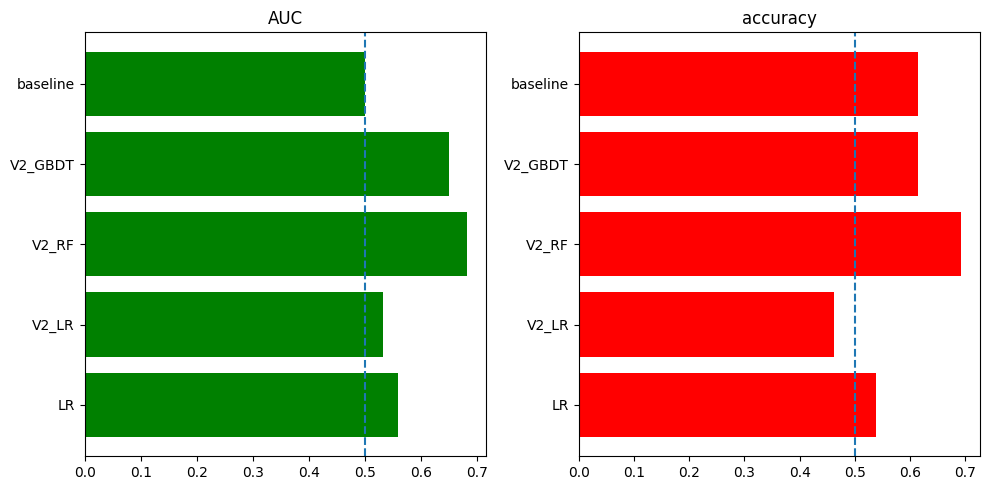

In [722]:
# TODO 9.3：画 V1 vs V2 指标对比图
#
# 建议画两个子图并排：
#   左图：各模型 AUC（barh），画一条 x=0.5 的虚线表示随机猜测
#   右图：各模型 Accuracy（barh），画一条 Baseline 虚线
#
# 颜色建议：V2 模型用绿色系，V1 用红色系，直观区分
#
# 保存到：reports/figures/v2_model_compare.png
#   Path('../reports/figures').mkdir(parents=True, exist_ok=True)

# 你来写代码
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("AUC")
plt.barh(results['model'],results['roc_auc'],color='g')
plt.axvline(0.5,linestyle='--')
plt.subplot(1,2,2)
plt.title('accuracy')
plt.barh(results['model'],results['accuracy'],color='r')
plt.axvline(0.5,linestyle='--')
plt.tight_layout()
plt.savefig('../reports/figures/v2_model_compare.png',dpi=300,bbox_inches='tight')
plt.show()

---
## 步骤 10 · 特征重要性与业务解释

### 思路

如果最优模型是树模型，可以看 `feature_importances_`。

这一步不是为了炫技，而是为了回答：

- 战队近期状态重要吗？
- BP 英雄强度重要吗？
- 战队英雄熟练度重要吗？
- 新英雄/低样本英雄是否让模型更不确定？

注意：特征重要性不等于因果。它只能说明模型在当前数据上依赖了哪些变量。

In [723]:
# TODO 10.1：选择 AUC 最高的 V2 模型，画特征重要性
#
# 从 results_df 里找 V2 最佳模型：
#   best_name = results_df[results_df['model'].str.contains('V2')].iloc[0]['model']
#   best_model = models_v2[best_name]
#
# 如果是树模型（RF/GBDT），用 feature_importances_
# 如果是 LR，用 np.abs(coef_[0])（注意已标准化）
#
# 画横向条形图（barh），按重要性从低到高排列
# 保存到 reports/figures/v2_feature_importance.png
#
# 思考：哪类特征最重要？战队状态 vs 英雄强度 vs 战队英雄熟练度？

# 你来写代码
v2_results = results[results['model'].str.contains('V2')]

best_name = v2_results.loc[
    v2_results['roc_auc'].idxmax(),
    'model'
]

best_model = models_v2[best_name]

In [724]:
best_name

'V2_RF'

In [725]:
best_model.feature_importances_

array([0.03612595, 0.10213499, 0.05940094, 0.03692504, 0.11191773,
       0.10287451, 0.09087876, 0.09873705, 0.14609066, 0.06597126,
       0.02385397, 0.01896517, 0.04302728, 0.02411052, 0.03898618])

<BarContainer object of 15 artists>

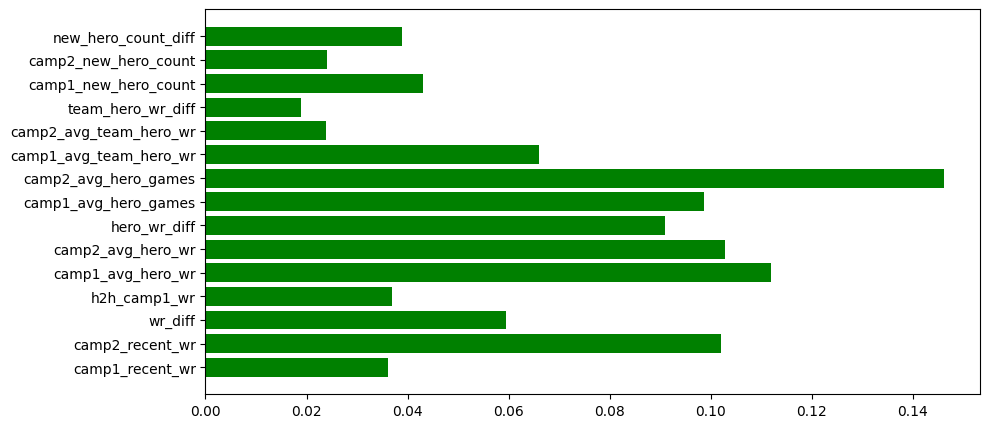

In [726]:
plt.figure(figsize=(10,5))
plt.barh(v2_features,best_model.feature_importances_,color='g')

In [727]:
# TODO 10.2：错误案例分析
#
# 找出 best_model 在测试集上预测错误的比赛：
#   test_battles = battles.iloc[split_idx:].copy()
#   test_battles['y_true'] = y_test.values
#   test_battles['y_pred'] = v2_preds[best_name]
#   test_battles['y_prob'] = v2_probs[best_name]
#
# 输出错误案例的：battle_id / camp1_team_name / camp2_team_name / y_true / y_prob
#
# 思考几个问题（写在 markdown 或注释里）：
#   - 错误案例有什么共性？是强队爆冷？还是模型对某些队伍没信息？
#   - y_prob 接近 0.5 说明模型不确定，接近 0 或 1 但错了说明模型"自信地犯错"

# 你来写代码
test_battles = battles.iloc[split_idx:].copy()
test_battles['y_true'] = y_test.values
test_battles['y_pred'] = v2_preds[best_name]
test_battles['y_prob'] = v2_probs[best_name]

In [728]:
test_battles[test_battles['y_true']!=test_battles['y_pred']]

,battle_id,status,win_camp,game_duration,battle_seq,camp1_team_id,camp1_team_name,camp1_team_icon,camp1_is_win,camp1_kill_num,...,camp1_avg_team_hero_games,camp1_new_hero_count,camp2_avg_team_hero_wr,camp2_avg_team_hero_games,camp2_new_hero_count,team_hero_wr_diff,new_hero_count_diff,y_true,y_pred,y_prob
102,736117264_133_1777809862,2,1,916.0,3,10020,北京JDG,https://smhtv-pic.tga.qq.com/bc18df69dd9164340...,True,13,...,0.2,4,1.000000,0.4,3,-1.000000,1,1,0,0.359021
107,736117264_15_1778222070,2,1,915.0,2,10020,北京JDG,https://smhtv-pic.tga.qq.com/bc18df69dd9164340...,True,12,...,1.2,0,0.500000,1.0,1,0.500000,-1,1,0,0.436943
109,736117264_17_1778225827,2,2,937.0,4,10020,北京JDG,https://smhtv-pic.tga.qq.com/bc18df69dd9164340...,False,3,...,1.2,2,0.875000,1.2,1,-0.208333,1,0,1,0.609504
114,736117264_22_1778243842,2,2,743.0,4,10031,杭州LGD.NBW,https://smhtv-pic.tga.qq.com/a29bcb1a579369888...,False,6,...,0.6,2,0.388889,1.4,2,0.611111,0,0,1,0.761509
117,736117264_25_1778248850,2,1,1380.0,7,10031,杭州LGD.NBW,https://smhtv-pic.tga.qq.com/a29bcb1a579369888...,True,12,...,2.2,1,0.833333,3.0,0,0.083333,1,1,0,0.314680
123,736117264_35_1778326511,2,1,1083.0,2,10027,成都AG超玩会,https://smhtv-pic.tga.qq.com/02e0582db3b0766ad...,True,19,...,0.2,4,0.750000,0.8,3,0.250000,1,1,0,0.362124
124,736117264_36_1778328510,2,1,819.0,3,10027,成都AG超玩会,https://smhtv-pic.tga.qq.com/02e0582db3b0766ad...,True,15,...,1.4,1,0.500000,1.2,1,0.125000,0,1,0,0.443269
125,736117264_37_1778330358,2,1,990.0,4,10002,上海EDG.M,https://smhtv-pic.tga.qq.com/7209fb2509e991052...,True,11,...,1.2,1,0.375000,1.2,1,0.500000,0,1,0,0.372405


---
## 步骤 11 · 保存 V2 模型

### 思路

保存的不只是模型，还要保存：

- `model`
- `feature_columns`
- `feature_version`
- `metrics`
- `trained_at`

这样以后做 Streamlit 或接口预测时，才能保证新数据列名和训练时完全一致。

In [729]:
# TODO 11.1：保存最优 V2 模型到 output/models/v2_bp_features.joblib
#
# 保存一个字典，包含：
#   - model: best_model 对象
#   - scaler: 如果是 LR 就保存 scaler_v2，否则 None
#   - feature_columns: v2_features 列表
#   - feature_version: 'v2_bp'
#   - metrics: 从 results_df 里取出该模型的指标 dict
#   - trained_at: datetime.now().isoformat()
#   - train_size / test_size
#
# 做法：
#   import joblib
#   from datetime import datetime
#   model_dir = Path('../output/models')
#   model_dir.mkdir(parents=True, exist_ok=True)
#   joblib.dump(artifact, model_dir / 'v2_bp_features.joblib')
#
# 为什么要存这么多信息？——以后做 Streamlit 时需要知道用哪些特征、要不要标准化
import  joblib
from datetime import datetime
# 你来写代码

# ===== 取 metrics =====
metrics = results[results['model'] == best_name].iloc[0].to_dict()

# ===== scaler 逻辑 =====
scaler = scaler_v2 if best_name in ['V2_LR'] else None

artifact = {
    'model': best_model,
    'scaler': scaler,
    'feature_columns': v2_features,
    'feature_version': 'v2_bp',
    'metrics': metrics,
    'trained_at': datetime.now().isoformat(),
    'train_size': len(y_test) if 'y_test' in globals() else None,
    'test_size': len(y_test)
}

In [730]:

model_dir = Path('../output/models')
model_dir.mkdir(parents = True,exist_ok = True)
joblib.dump(artifact,model_dir/'v2_bp_features.jonblib')

['..\\output\\models\\v2_bp_features.jonblib']

---
## ✅ 完成自检

请你跑完后逐项打勾：

- [ ] 我没有使用 `gold / kill / push_tower / hurt_total / game_duration` 等赛后字段作为特征
- [ ] 英雄历史胜率使用了 `shift(1)`，没有包含本场结果
- [ ] 战队英雄熟练度使用了 `shift(1)`，没有包含本场结果
- [ ] 历史交手特征使用的是 `h2h_camp1_wr`，不是方向不稳定的 `history_win_rate`
- [ ] 训练/测试切分是时间序列切分，不是随机切分
- [ ] 我对比了 baseline / V1 / V2
- [ ] 我保存了 V2 模型文件
- [ ] 我写完了下面的总结报告

---

## 总结报告（必须填写）

### 1. V2 新增了哪些特征？

请写：

- 英雄历史强度特征：
- 战队英雄熟练度特征：
- 阵容差值特征：

### 2. V2 相比 V1 有没有提升？

请用数字回答，不要只写“提升了/没提升”。

- V1 Accuracy / AUC：
- V2 Accuracy / AUC：
- 是否超过 baseline：

### 3. 哪些特征最重要？

请结合特征重要性图写 2-3 句业务解释。

### 4. V2 的不足是什么？

建议从这些角度写：

- 样本量是否太少？
- 英雄胜率是否容易受版本影响？
- 战队英雄熟练度是否太稀疏？
- 没有实时快照时，为什么还不能叫真正的实时胜率模型？

### 5. 下一步 V3 怎么做？

请写出真正实时模型需要的数据：

- 每隔 N 秒抓取一次 battle/open
- 保存 battle_id + timestamp + gold/kill/tower 等赛中快照
- 用第 3/5/8/10 分钟特征预测最终胜负
